<a href="https://colab.research.google.com/github/OmkarTanawade/3Column/blob/main/Untitled0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install yfinance pandas numpy matplotlib scikit-learn tensorflow

In [2]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

In [19]:
stock = "TATASTEEL.BO"
data = yf.download(stock, start="2015-01-01", end="2026-02-20")

data = data[['Close']]
data.head()

/tmp/ipython-input-3478804859.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stock, start="2015-01-01", end="2026-02-20")
[*********************100%***********************]  1 of 1 completed


Price,Close
Ticker,TATASTEEL.BO
Date,
2015-01-01,2.895858
2015-01-02,2.940597
2015-01-05,2.982472
2015-01-06,2.836803
2015-01-07,2.788485


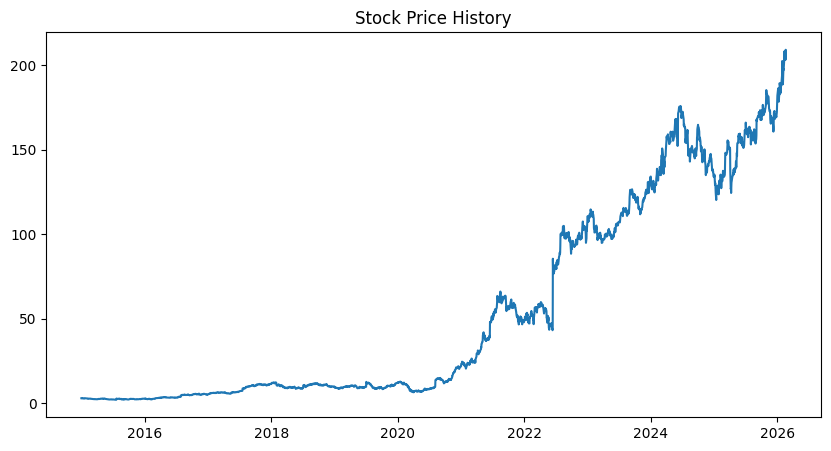

In [20]:
plt.figure(figsize=(10,5))
plt.plot(data['Close'])
plt.title("Stock Price History")
plt.show()

In [5]:
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

In [6]:
train_size = int(len(scaled_data) * 0.8)
train_data = scaled_data[:train_size]

X_train = []
y_train = []

for i in range(60, len(train_data)):
    X_train.append(train_data[i-60:i, 0])
    y_train.append(train_data[i, 0])

X_train, y_train = np.array(X_train), np.array(y_train)

X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

In [8]:
model = Sequential()

model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1],1)))
model.add(LSTM(units=50))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(X_train, y_train, epochs=20, batch_size=32)

Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - loss: 0.0067
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 60ms/step - loss: 3.0223e-04
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 1.9042e-04
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 2.3489e-04
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 1.4043e-04
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - loss: 1.7274e-04
Epoch 7/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - loss: 1.6568e-04
Epoch 8/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 1.8483e-04
Epoch 9/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 1.9318e-04
Epoch 10/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - loss: 1.1281e-04
Epoch 11/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 1.1495e-04
Epoch 12/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - loss: 2.3412e-04
Epoch 13/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 9.2212e-05
Epoch 14/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - loss: 1.4606e-04
Epoch 15/20
60/60 ━

In [9]:
test_data = scaled_data[train_size-60:]

X_test = []
y_test = scaled_data[train_size:]

for i in range(60, len(test_data)):
    X_test.append(test_data[i-60:i, 0])

X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

In [10]:
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)

real_prices = scaler.inverse_transform(y_test.reshape(-1,1))

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step


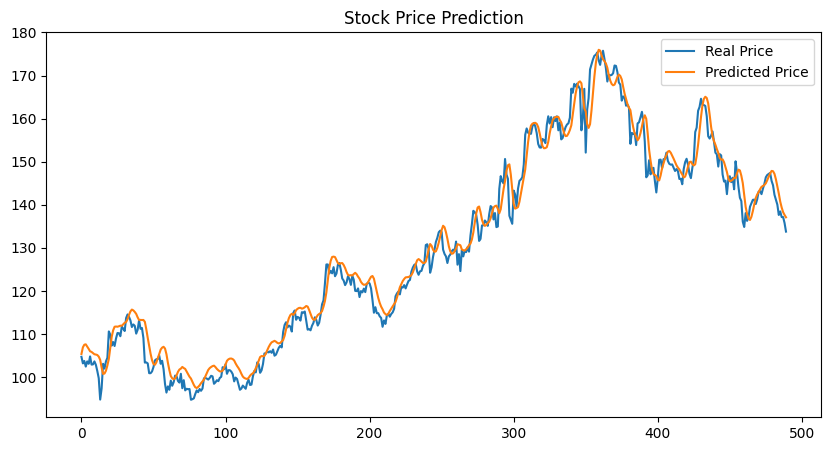

In [24]:
plt.figure(figsize=(10,5))
plt.plot(real_prices, label="Real Price")
plt.plot(predictions, label="Predicted Price")
plt.legend()
plt.title("Stock Price Prediction")
plt.show()

In [23]:
last_60_days = scaled_data[-60:]
X_future = []
X_future.append(last_60_days[:,0])
X_future = np.array(X_future)
X_future = np.reshape(X_future, (X_future.shape[0], X_future.shape[1], 1))

future_prices = []

for i in range(30):
    pred = model.predict(X_future)
    future_prices.append(pred[0,0])

    # Reshape pred to (1, 1, 1) to match dimensions for appending
    X_future = np.append(X_future[:,1:,:], pred.reshape(1, 1, 1), axis=1)

future_prices = scaler.inverse_transform(np.array(future_prices).reshape(-1,1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━

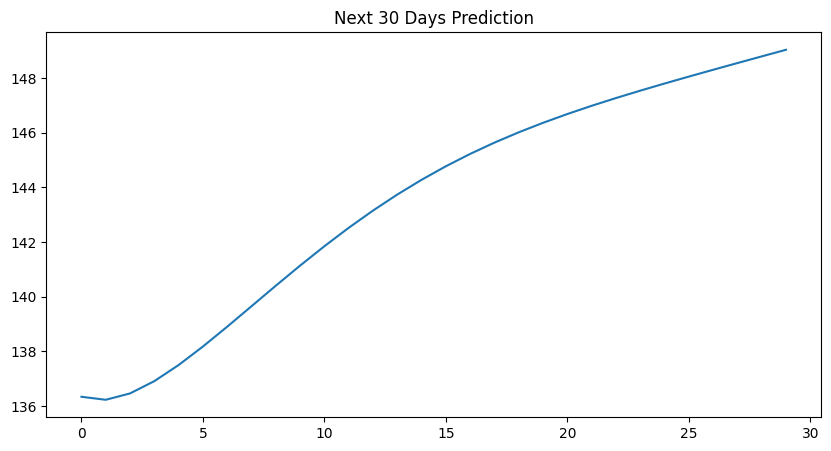

In [22]:
plt.figure(figsize=(10,5))
plt.plot(future_prices)
plt.title("Next 30 Days Prediction")
plt.show()

Current Price (as of 2026-02-19): 205.45


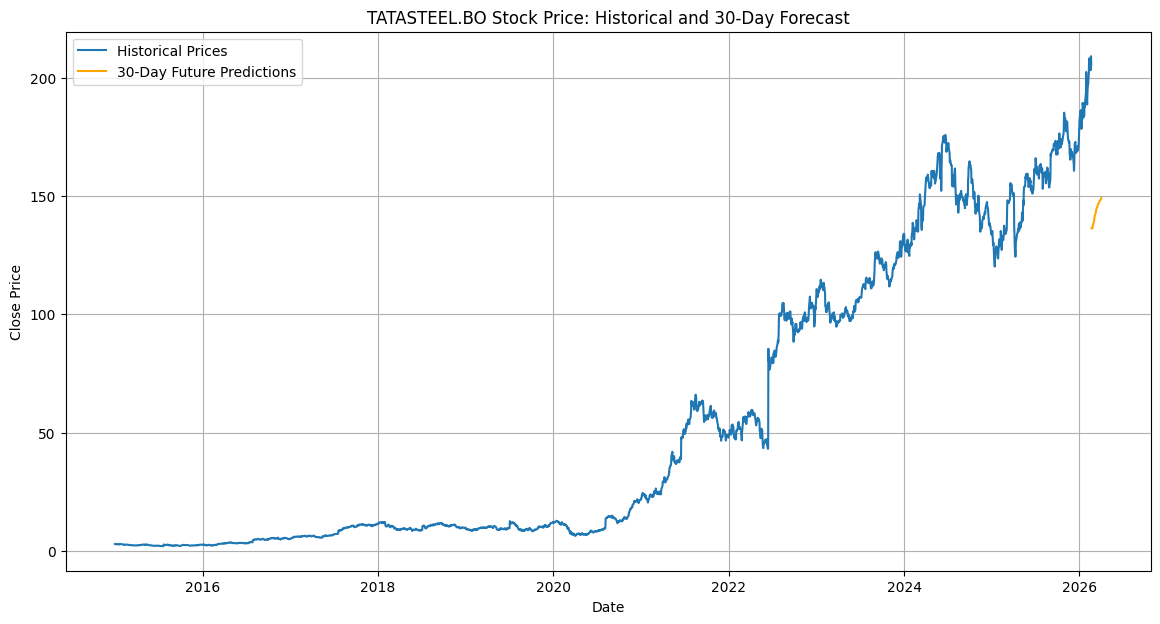

Expected approximate price for the next 30 days: 143.48
Expected approximate price for the upcoming week: 137.22


In [27]:
last_date = data.index[-1]
current_price = data['Close'].iloc[-1]
print(f"Current Price (as of {last_date.strftime('%Y-%m-%d')}): {current_price.item():.2f}")

future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=30, freq='B') # 'B' for business day frequency

plt.figure(figsize=(14,7))
plt.plot(data['Close'], label='Historical Prices')
plt.plot(future_dates, future_prices, label='30-Day Future Predictions', color='orange')
plt.title(f'{stock} Stock Price: Historical and 30-Day Forecast')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.show()

print(f"Expected approximate price for the next 30 days: {np.mean(future_prices):.2f}")
print(f"Expected approximate price for the upcoming week: {np.mean(future_prices[:7]):.2f}")